In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline


import jaydebeapi
from pathlib import Path
import os
import pandas as pd
import csv
from datetime import date
from datetime import datetime
from xirr.math import xirr

In [102]:
# f = open("C:\\Users\\111075866\\Downloads\\stocks_28Nov.csv")
fileName = 'mf_21_aug-2024.csv'
f = open("C:\\Users\\111075866\\Downloads\\"+fileName)
mf = [0,6,7,14,12]
stk = [0,7,8,15,13]

##for stock use stk, for mutualfund use mf
cols = mf
# cols = stk
# Make sure to remove the totals row in the xl sheet from moneycontrol

In [103]:
# f.name


In [104]:
# f.close()
stks = pd.read_csv(f)


In [105]:
stks 

,ï»¿Scheme,Latest NAV,Change,Prev NAV,Quantity,Inv. Price,Inv. Date,Inv. Amt,52 Wk High/Low,Todays Gain,Todays Gain%,Overall Gain,Overall Gain%,Realised Gains,Latest Value,Broker,Notes
0,HDFC Dividend Yield Fund - Direct Plan - Growth,27.2320,0.1830,27.0490,183.608,27.2320,21-08-2024,5000.013056,27.49 / 18.54,34,0.68,0,0.00,NaN,5000,-,-
1,ICICI Prudential Nifty Pharma Index Fund - Dir...,17.2793,0.1050,17.1743,291.790,17.1360,15-08-2024,5000.113440,17.28 / 11.32,31,0.61,42,0.84,NaN,5042,-,-
2,SBI Gold Fund - Direct Plan - Growth,22.4121,0.0896,22.3225,227.565,21.9720,15-08-2024,5000.058180,23.25 / 17.81,20,0.40,100,2.00,NaN,5100,-,-
3,ICICI Prudential Multi-Asset Fund - Direct Pla...,763.4421,3.1255,760.3166,13.359,748.5502,06-08-2024,9999.882122,765.59 / 580.61,42,0.41,199,1.99,NaN,10199,-,-
4,ICICI Prudential Nifty IT Index Fund - Direct ...,14.2432,0.1148,14.1284,379.521,13.1750,05-08-2024,5000.189175,14.24 / 10.25,44,0.81,405,8.11,NaN,5406,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,67.100,74.4100,07-01-2015,4992.911000,314.71 / 217.60,138,0.66,15956,319.58,NaN,20949,-,-
293,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,65.898,75.8744,01-01-2015,4999.971211,314.71 / 217.60,135,0.66,15574,311.48,NaN,20574,-,-
294,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,67.950,73.5837,01-12-2014,5000.012415,314.71 / 217.60,139,0.66,16215,324.29,NaN,21215,-,-
295,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,309.612,73.8851,29-11-2014,22875.713580,314.71 / 217.60,635,0.66,73788,322.56,NaN,96664,-,-


In [106]:
t = stks.shape[0]-1
stks = stks.iloc[0:stks.shape[0]-1]

In [107]:
stks

,ï»¿Scheme,Latest NAV,Change,Prev NAV,Quantity,Inv. Price,Inv. Date,Inv. Amt,52 Wk High/Low,Todays Gain,Todays Gain%,Overall Gain,Overall Gain%,Realised Gains,Latest Value,Broker,Notes
0,HDFC Dividend Yield Fund - Direct Plan - Growth,27.2320,0.1830,27.0490,183.608,27.2320,21-08-2024,5000.013056,27.49 / 18.54,34,0.68,0,0.00,NaN,5000,-,-
1,ICICI Prudential Nifty Pharma Index Fund - Dir...,17.2793,0.1050,17.1743,291.790,17.1360,15-08-2024,5000.113440,17.28 / 11.32,31,0.61,42,0.84,NaN,5042,-,-
2,SBI Gold Fund - Direct Plan - Growth,22.4121,0.0896,22.3225,227.565,21.9720,15-08-2024,5000.058180,23.25 / 17.81,20,0.40,100,2.00,NaN,5100,-,-
3,ICICI Prudential Multi-Asset Fund - Direct Pla...,763.4421,3.1255,760.3166,13.359,748.5502,06-08-2024,9999.882122,765.59 / 580.61,42,0.41,199,1.99,NaN,10199,-,-
4,ICICI Prudential Nifty IT Index Fund - Direct ...,14.2432,0.1148,14.1284,379.521,13.1750,05-08-2024,5000.189175,14.24 / 10.25,44,0.81,405,8.11,NaN,5406,-,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
291,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,66.877,74.7640,07-02-2015,4999.992028,314.71 / 217.60,137,0.66,15880,317.59,NaN,20880,-,-
292,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,67.100,74.4100,07-01-2015,4992.911000,314.71 / 217.60,138,0.66,15956,319.58,NaN,20949,-,-
293,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,65.898,75.8744,01-01-2015,4999.971211,314.71 / 217.60,135,0.66,15574,311.48,NaN,20574,-,-
294,UTI Mid Cap Fund - Growth,312.2106,2.0514,310.1592,67.950,73.5837,01-12-2014,5000.012415,314.71 / 217.60,139,0.66,16215,324.29,NaN,21215,-,-


In [108]:
stks = stks.iloc[:, cols ]


In [109]:
stks.columns = ['Stock', 'Inv. Date', 'Inv. Amt', 'Latest Value', 'Overall Gain']

In [110]:
g = stks.groupby(by=["Stock"])

In [111]:
# stks[["Inv. Date"]].map(lambda x: str(x)).map(lambda x: str(x[6:]))

In [112]:
import datetime

In [113]:
g1 = pd.DataFrame(g.sum()["Latest Value"])
g1["Inv. Amt"] = g1["Latest Value"]*-1
i = g1.index
g1["Stock"] = i.values
stk_name = i.values
g1["Inv. Date"] = datetime.date.today()
stks["Inv. Date"] = stks[["Inv. Date"]].map(lambda x: str(x)).map(lambda x: datetime.date(int(x[6:]), int(x[3:5]), int(x[:2])))
# stks[["Inv. Date"]].map(lambda x: str(x)).map(lambda x: int(x[:2]))

C:\Users\111075866\AppData\Local\Temp\ipykernel_19352\1334390569.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stks["Inv. Date"] = stks[["Inv. Date"]].map(lambda x: str(x)).map(lambda x: datetime.date(int(x[6:]), int(x[3:5]), int(x[:2])))


In [114]:
s=g1

In [115]:
ta = s[["Inv. Amt", "Stock","Inv. Date"]]
stks1 = pd.concat([stks, ta])

In [116]:
inp = stks1[["Stock", "Inv. Amt", "Inv. Date"]]

In [117]:
# inp
# stk_name = i.values
# stk_name

In [118]:
# inp[["Inv. Amt"]].map( lambda amt: -1*amt if amt < 0 else 0)
sum(inp[["Inv. Amt"]].to_numpy())[0]
# print(inp[["Inv. Amt"]].sum())

-5969266.801100002

In [119]:
r = (datetime.date.today()  - min(inp["Inv. Date"]) ) 
print(r)

3553 days, 0:00:00


In [120]:
r.days/365

9.734246575342466

In [121]:
#Test one

In [122]:
from xirr.math import xirr
# xirr(inp[[ "Inv. Date"]], inp[[ "Latest Value"]])
# x = datetime.date.today()
# x.month

s = []
print("{Stock}  - \t \t :  {XIRR}:  {current_value} : \t {abs_ret} : \t {avg_ret} : \t {strt_date} : \t {age}")
for stk in stk_name:
    t1 = inp[inp["Stock"] == stk]
    print ("------------------------------------------------------------------------------------------------")
    # print(t1)
    vperdate = dict(zip(t1["Inv. Date"], t1["Inv. Amt"]))
    strt_date = min(t1["Inv. Date"])
    age = (datetime.date.today() - min(t1["Inv. Date"])).days/365
    # print(min(t1["Inv. Date"]),t1["Inv. Date"] )
    # t1[["Inv. Amt"]].filter()
    inv_amount = sum(t1[["Inv. Amt"]].map( lambda amt: amt if amt > 0 else 0).to_numpy())[0]
    current_value = sum(t1[["Inv. Amt"]].map( lambda amt: -1*amt if amt < 0 else 0).to_numpy())[0]
    abs_ret = current_value/inv_amount-1
    avg_ret = abs_ret/age
    # print( "{}  - \t \t : {} \t \t:  {} \t \t :  {} : \t {} ".format(stk, xirr(vperdate),inv_amount, current_value,abs_ret ))
    xr = xirr(vperdate)
    print( "{}\t:{} :  {} : \t {} : \t {} : \t {} : \t {} ".format(stk,xr,current_value,abs_ret,avg_ret,strt_date,age ))
    s.append((stk,xr,inv_amount,current_value,abs_ret,avg_ret,strt_date,age))
    # print ()
# s

{Stock}  - 	 	 :  {XIRR}:  {current_value} : 	 {abs_ret} : 	 {avg_ret} : 	 {strt_date} : 	 {age}
------------------------------------------------------------------------------------------------
Aditya Birla Sun Life Frontline Equity Fund - Direct Plan - Growth	:0.1672318808292997 :  636913.0 : 	 1.6674936413354948 : 	 0.20348885960797577 : 	 2016-06-13 : 	 8.194520547945206 
------------------------------------------------------------------------------------------------
Aditya Birla Sun Life Liquid Fund - Direct Plan - Growth	:0.07503811940668614 :  31983.0 : 	 0.06739342679363824 : 	 0.07476778352485702 : 	 2023-09-27 : 	 0.9013698630136986 
------------------------------------------------------------------------------------------------
Bandhan Government Securities Fund - Investment Plan - Direct Plan - Growth	:0.08975580877831271 :  480397.0 : 	 0.610537514956355 : 	 0.07874423779472423 : 	 2016-11-21 : 	 7.7534246575342465 
----------------------------------------------------------

In [123]:
# n = inp[["Inv. Amt"]].sum() 
# print(n)

In [124]:
p1 = pd.DataFrame(g.sum()[["Inv. Amt","Latest Value"]])
# p1["Stock"] = p1.index.values
p2 = pd.DataFrame(s)

In [125]:
p2.columns=["Stock", "XIRR","Total Investment", "Current Value","abs_ret","avg_ret","start_date","age"]
m = p1.join(p2.set_index("Stock"))

In [126]:
str_tz = str(datetime.datetime.now()).replace(' ', '_').replace(':','_').replace('.','_')
print(str_tz)

2024-08-21_10_42_54_283487


In [127]:
m.to_csv("C:\\Users\\111075866\\Downloads\\"+fileName+"-XIRR-"+str_tz+".csv")
inp.to_csv("C:\\Users\\111075866\\Downloads\\"+fileName+"-upd-"+str_tz+".csv")

In [128]:
inp

,Stock,Inv. Amt,Inv. Date
0,HDFC Dividend Yield Fund - Direct Plan - Growth,5000.013056,2024-08-21
1,ICICI Prudential Nifty Pharma Index Fund - Dir...,5000.113440,2024-08-15
2,SBI Gold Fund - Direct Plan - Growth,5000.058180,2024-08-15
3,ICICI Prudential Multi-Asset Fund - Direct Pla...,9999.882122,2024-08-06
4,ICICI Prudential Nifty IT Index Fund - Direct ...,5000.189175,2024-08-05
...,...,...,...
SBI Gold Fund - Direct Plan - Growth,SBI Gold Fund - Direct Plan - Growth,-25132.000000,2024-08-21
Tata India Pharma & Heathcare Fund - Direct Plan - Growth,Tata India Pharma & Heathcare Fund - Direct Pl...,-296880.000000,2024-08-21
UTI Dividend Yield Fund - Direct Plan - IDCW,UTI Dividend Yield Fund - Direct Plan - IDCW,-409426.000000,2024-08-21
UTI Large & Mid Cap Fund - Direct Plan - Growth,UTI Large & Mid Cap Fund - Direct Plan - Growth,-203777.000000,2024-08-21


In [129]:
inp.describe()

,Inv. Amt
count,3.360000e+02
mean,-1.776568e+04
std,2.094556e+05
min,-2.973432e+06
25%,4.999996e+03
50%,9.999963e+03
75%,1.000001e+04
max,1.236178e+06


In [130]:
c = inp.loc[inp["Inv. Amt"]>0].pivot_table(values=["Inv. Amt"], index=["Stock"],aggfunc="sum").replace(np.nan, 0)
c.nlargest(5, columns=["Inv. Amt"])

# pivot_table(values=["Inv. Amt"], index=["Stock"],aggfunc="sum").replace(np.nan, 0)

,Inv. Amt
Stock,
HDFC Top 100 Fund - Direct Plan - Growth,1.236178e+06
ICICI Prudential Multi-Asset Fund - Direct Plan - Growth,5.299901e+05
HDFC Dividend Yield Fund - Direct Plan - Growth,4.292167e+05
Canara Robeco Bluechip Equity Fund - Direct Plan - Growth,4.053932e+05
Bandhan Government Securities Fund - Investment Plan - Direct Plan - Growth,2.982836e+05


array([<Axes: ylabel='Inv. Amt'>], dtype=object)

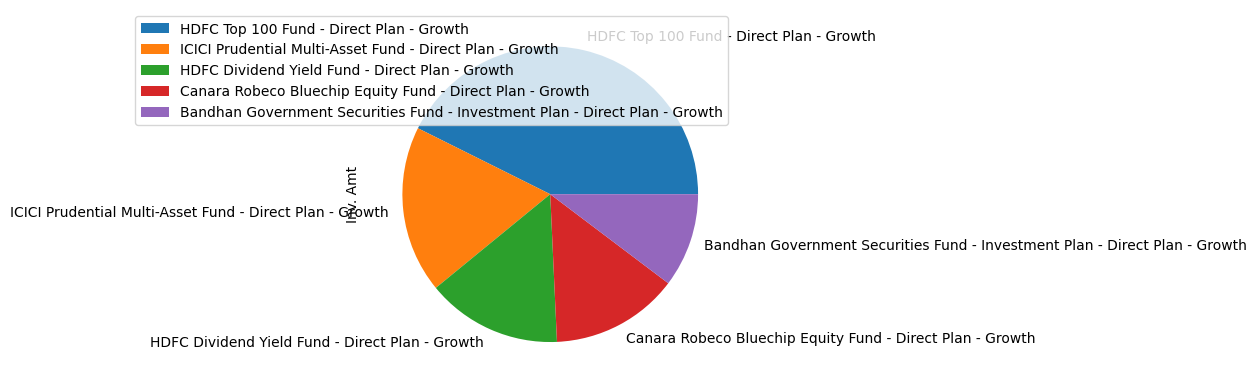

In [131]:
c.nlargest(5, columns=["Inv. Amt"]).plot(kind="pie", subplots=True)

In [132]:
cut1 = pd.cut(c["Inv. Amt"],4)
type(cut1)

pandas.core.series.Series